### Import Libraries

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
sns.set_theme(
    rc={'axes.axisbelow': True},
    style={
        "axes.facecolor": "#F8FAF9",   # cloud white background
        "axes.edgecolor": "#1B3A3A",   # deep teal edges
        "patch.edgecolor": "#2A9D8F",
        "patch.force_edgecolor": True,
        "grid.color": "#DCE7E4",
        "axes.grid": True
    }
)
sns.set_palette([
    "#0F6F63",  # deep jade (primary metrics)
    "#2A9D8F",  # soft jade
    "#7BC8A4",  # light jade
    "#FFD84D",  # alert yellow
    "#EEF4F2",  # soft white
    "#1B3A3A",  # deep teal contrast
    "#A8D5C2"   # pastel jade
])

np.set_printoptions(suppress=True)

pd.set_option('display.float_format', '{:.2f}'.format) #set float display format

### Set Variables

In [4]:
# Set Variables
DATASET = "datasets/cloud_metrics/metrics.csv"
TIMESTAMP = "timestamp"
ID_COLUMNS = ["vm_id"]

### Load Dataset & Overview

In [5]:
df = pd.read_csv(DATASET)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 12 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   vm_id                      object 
 1   timestamp                  object 
 2   cpu_usage                  float64
 3   memory_usage               float64
 4   network_traffic            float64
 5   power_consumption          float64
 6   num_executed_instructions  float64
 7   execution_time             float64
 8   energy_efficiency          float64
 9   task_type                  object 
 10  task_priority              object 
 11  task_status                object 
dtypes: float64(7), object(5)
memory usage: 183.1+ MB


In [7]:
df.head()

,vm_id,timestamp,cpu_usage,memory_usage,network_traffic,power_consumption,num_executed_instructions,execution_time,energy_efficiency,task_type,task_priority,task_status
0,c5215826-6237-4a33-9312-72c1df909881,2023-01-25 09:10:54,54.88,78.95,164.78,287.81,7527.00,69.35,0.55,network,medium,waiting
1,29690bc6-1f34-403b-b509-a1ecb1834fb8,2023-01-26 04:46:34,71.52,29.90,NaN,362.27,5348.00,41.40,0.35,io,high,completed
2,2e55abc3-5bad-46cb-b445-a577f5e9bf2a,2023-01-13 23:39:47,NaN,92.71,203.67,231.47,5483.00,24.60,0.80,io,medium,completed
3,e672e32f-c134-4fbc-992b-34eb63bef6bf,2023-02-09 11:45:49,54.49,88.10,NaN,195.64,5876.00,16.46,0.53,compute,high,completed
4,f38b8b50-6926-4533-be4f-89ad11624071,2023-06-14 08:27:26,42.37,NaN,NaN,359.45,3361.00,55.31,0.35,NaN,medium,waiting


In [8]:
# change to date time since it is current in object form
df[TIMESTAMP] = pd.to_datetime(df[TIMESTAMP])

# drop id columns
df = df.drop(columns=ID_COLUMNS, axis=1)

# set the columns
df_numerical = df.describe(exclude=["datetime", "object"]).columns
df_categorical = df.describe(include="object").columns
df_time = df.describe(include="datetime").columns

In [9]:
print("Percentage of Null Values")
df.isnull().sum()/len(df)*100 

Percentage of Null Values


timestamp                   10.03
cpu_usage                    9.95
memory_usage                10.03
network_traffic              9.97
power_consumption           10.01
num_executed_instructions    9.98
execution_time               9.99
energy_efficiency           10.00
task_type                   10.00
task_priority                9.97
task_status                 10.02
dtype: float64

### Numerical Columns

In [10]:
# describe numerical columns
df.describe(exclude=["datetime", "object"])

,cpu_usage,memory_usage,network_traffic,power_consumption,num_executed_instructions,execution_time,energy_efficiency
count,1800962.00,1799490.00,1800519.00,1799729.00,1800314.00,1800173.00,1799958.00
mean,50.01,49.98,500.01,250.06,5001.90,49.97,0.50
std,28.88,28.85,288.58,144.36,2885.25,28.86,0.29
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,24.98,25.00,250.07,124.97,2504.00,24.98,0.25
50%,50.05,49.98,500.01,250.25,5002.00,49.96,0.50
75%,75.03,74.96,749.82,375.11,7502.00,74.98,0.75
max,100.00,100.00,1000.00,500.00,9999.00,100.00,1.00


In [11]:
df.skew(numeric_only=True)

cpu_usage                   -0.00
memory_usage                 0.00
network_traffic             -0.00
power_consumption           -0.00
num_executed_instructions   -0.00
execution_time               0.00
energy_efficiency           -0.00
dtype: float64

Text(0.5, 0.98, 'Numerical Values')

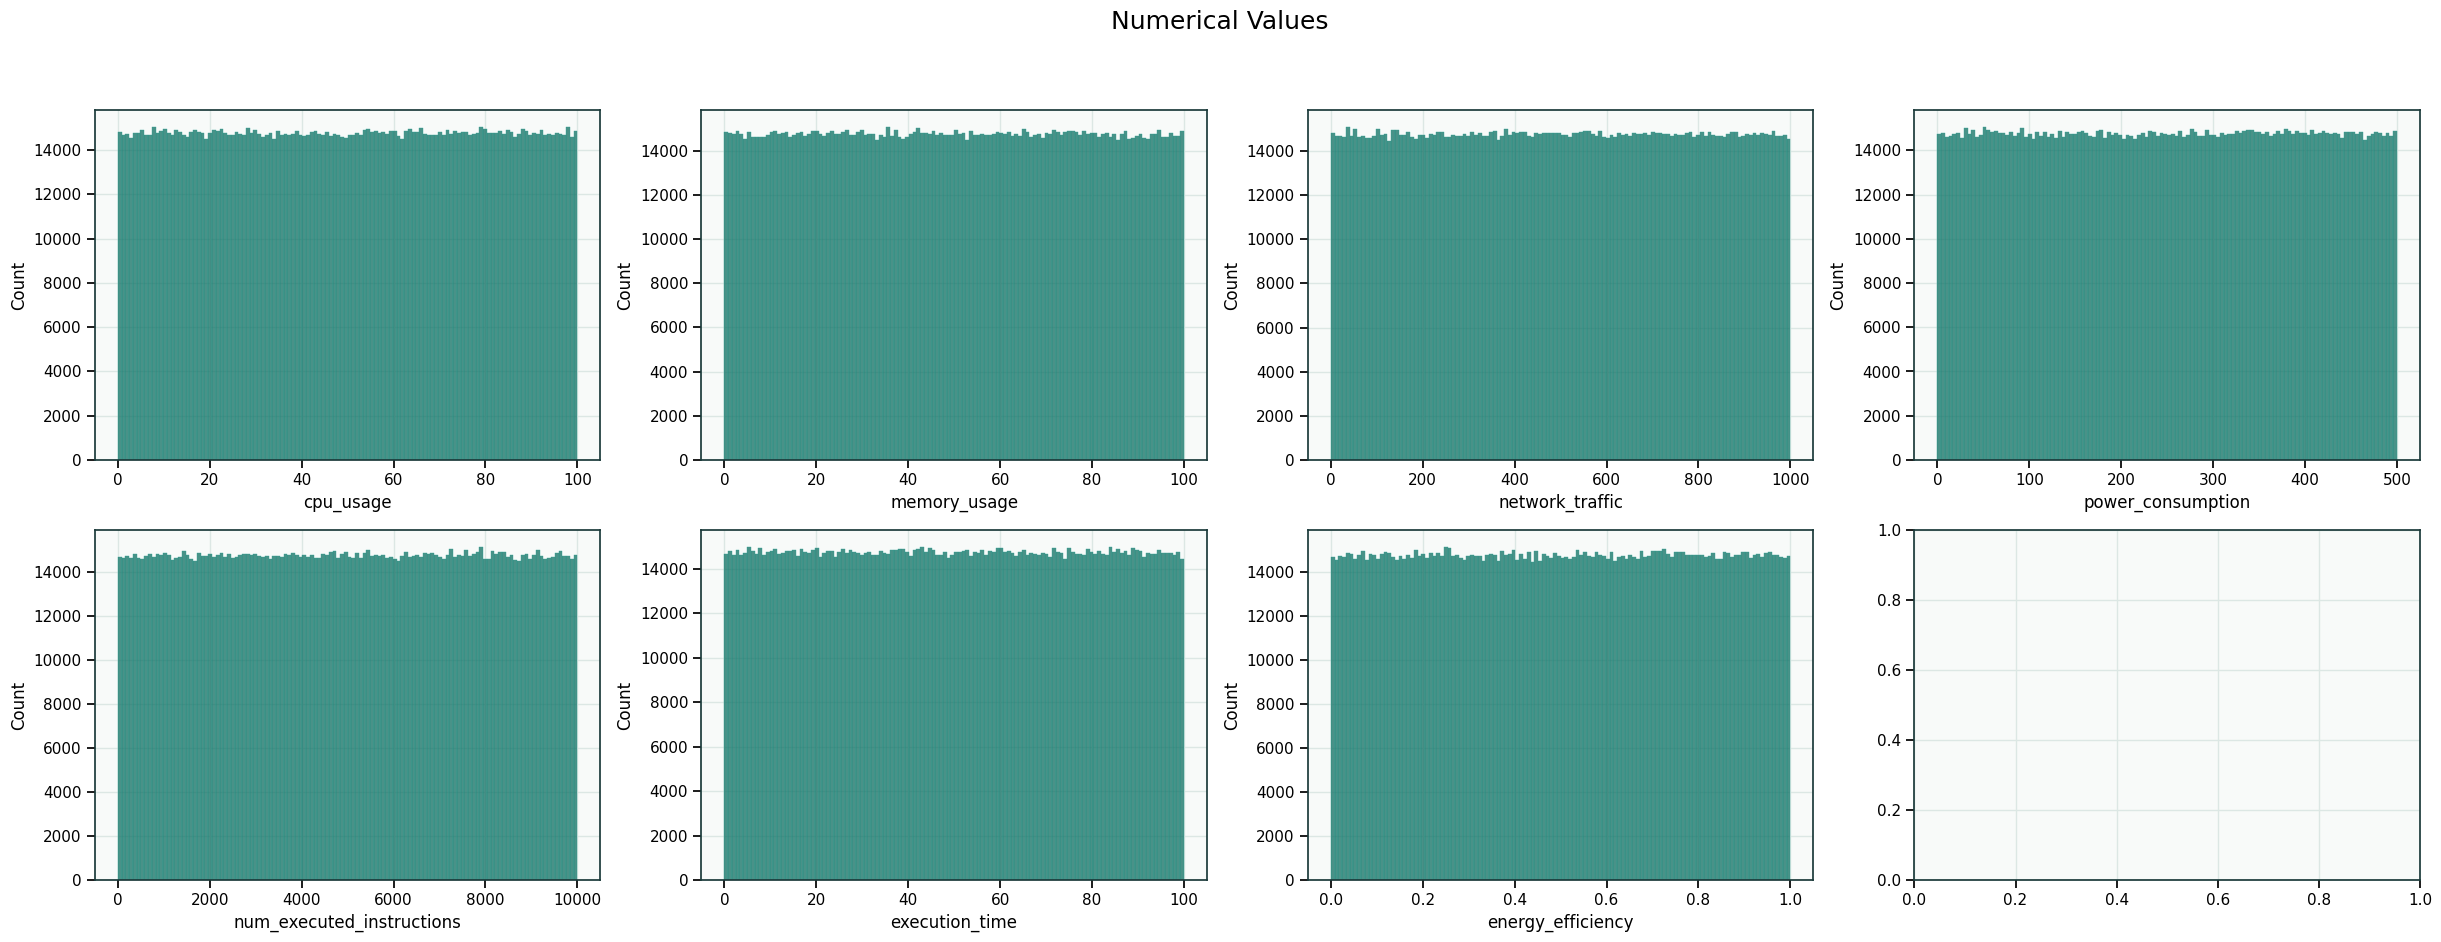

In [12]:
cols = round(len(df_numerical)/2)
rows = round(len(df_numerical)/cols)

fig, axs = plt.subplots(ncols = cols, nrows= rows, figsize=(30, 10))
axs = axs.flatten()
for i, col in enumerate(df_numerical):
    sns.histplot(df, x = col, ax=axs[i])

plt.suptitle("Numerical Values", fontsize = 18)

### Categorical Columns

In [13]:
# describe categorical columns
df.describe(include="object")

,task_type,task_priority,task_status
count,1800038,1800567,1799694
unique,3,3,3
top,io,medium,waiting
freq,600695,600700,600358


Text(0.5, 0.98, 'Categorical Values')

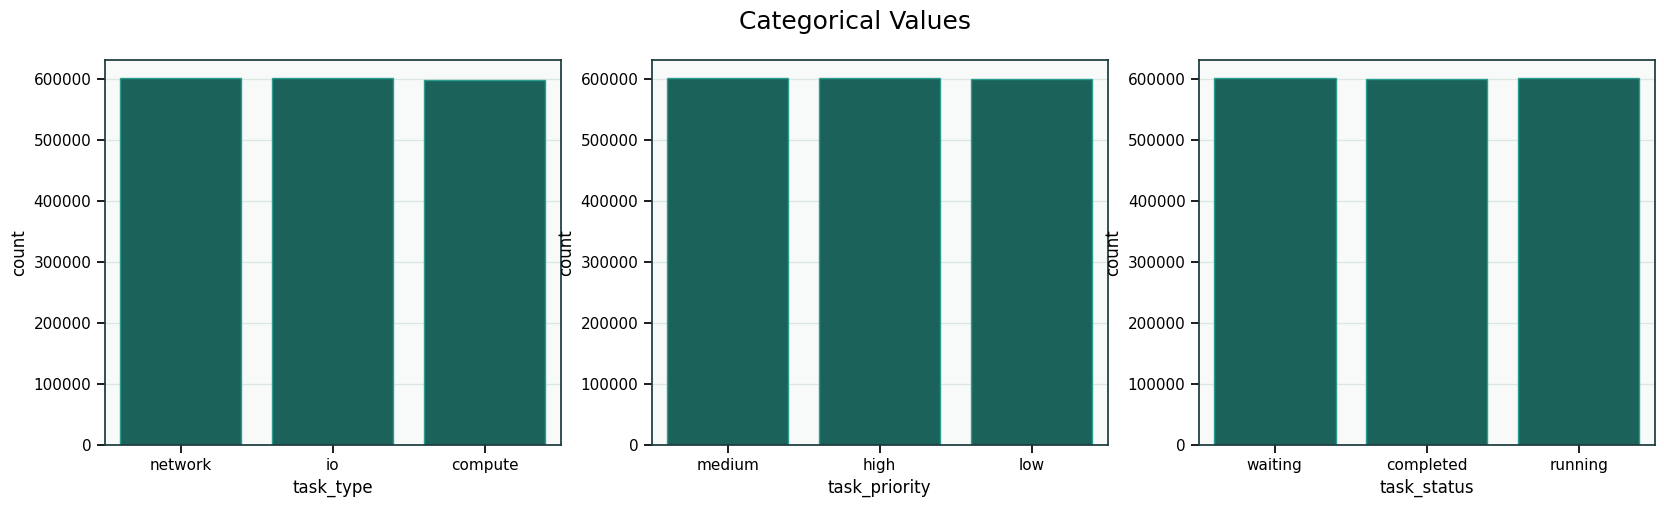

In [14]:
fig, axs = plt.subplots(ncols = len(df_categorical), figsize=(20, 5))

for i, col in enumerate(df_categorical):
    sns.countplot(df, x = col, ax=axs[i])

plt.suptitle("Categorical Values", fontsize = 18)

### Relationship between columns and time

In [15]:
# describe timecolumn
df.describe(include="datetime")

,timestamp
count,1799334
mean,2023-04-11 07:19:55.175783168
min,2023-01-01 00:00:09
25%,2023-02-20 04:34:56.249999872
50%,2023-04-11 07:56:02.500000
75%,2023-05-31 10:45:20.249999872
max,2023-07-20 12:04:18


the dataset contains 7 months worth of data, but only 1 month of data is needed for modelling purposes. Hence the latest one month of data is sampled for EDA.

## Data Pre-processing


#### Data Sampling

In [16]:
from sklearn.preprocessing import MinMaxScaler

In [17]:
df_filtered = df.loc[df.timestamp > "2023-07"] # only last one month of data

####  or


In [18]:
df_filtered = df.loc[df.timestamp > "2023-07-20"] # for one day of data

In [19]:
df_filtered.isnull().sum() # make sure no null values in timestamp for sample data

timestamp                      0
cpu_usage                    427
memory_usage                 464
network_traffic              439
power_consumption            460
num_executed_instructions    446
execution_time               470
energy_efficiency            450
task_type                    458
task_priority                439
task_status                  482
dtype: int64

In [20]:
df_sampled = df_filtered.sort_values(by = "timestamp").reset_index(drop = True).set_index("timestamp") # make time as index as sort value by it
df_sampled = df_sampled.loc[~df_sampled.index.duplicated()] # drop duplicated if any to avoid duplicated index

df_sampled = df_sampled.loc[:,["cpu_usage","memory_usage","network_traffic"]] # only keep numerical columns that will be used

In [21]:
df_sampled

,cpu_usage,memory_usage,network_traffic
timestamp,,,
2023-07-20 00:00:13,63.54,38.69,670.61
2023-07-20 00:00:15,96.73,31.65,445.82
2023-07-20 00:00:23,2.77,18.57,174.92
2023-07-20 00:00:41,16.79,NaN,245.71
2023-07-20 00:01:02,NaN,85.12,NaN
...,...,...,...
2023-07-20 12:03:21,57.98,97.25,247.73
2023-07-20 12:03:45,74.98,25.33,26.03
2023-07-20 12:03:53,54.38,7.27,538.40


#### Split data into Train & Test

In [22]:
# split dataset before filling missing values to avoid data leakage
split_index = int(len(df_sampled) * 0.7)

# Split the data
df_sampled_train = df_sampled.iloc[:split_index]
df_sampled_test = df_sampled.iloc[split_index:]

#### Preprocess data

In [23]:
def fillMissingValues(tsdf:pd.DataFrame):
    return tsdf.interpolate(method="time") 
    # interpolate to fill NA for time-series data to ensure NA are filled continously instead of randomly
    # "time" works with data time index as well

def resampleTimeData(tsdf:pd.DataFrame, interval: str):
    return tsdf.resample(interval).mean()
    # resample data into 5 minute intervals based on average

In [24]:
df_sampled_train = fillMissingValues(df_sampled_train)
df_sampled_test  = fillMissingValues(df_sampled_test)

df_sampled_train = resampleTimeData(df_sampled_train, interval="5min")
df_sampled_test  = resampleTimeData(df_sampled_test, interval="5min").iloc[1:] 
# remove the first row as it is the same sampled timestamp as last row of train

#### Feature Engineering

In [25]:
# create time-based features for each row
def createTimeFeatures(tsdf: pd.DataFrame):
    tsdf["hour"] = tsdf.index.hour
    tsdf["day"] = tsdf.index.day
    tsdf["day_of_week"] = tsdf.index.dayofweek
    tsdf["is_weekend"] = tsdf.index.dayofweek >= 5

    return tsdf

# feature creation for lag windows and rolling average
def createLagRollingFeatures(tsdf: pd.DataFrame, lags: int, rolling_window:int):
    columns = tsdf.columns
    for col in columns:
        for lag in range(1, lags + 1):
            tsdf[f"{col}_lag-{lag}"] = tsdf[col].shift(lag)
    # Create lag features for each column

    for col in columns:
        tsdf[f"{col}_rolling_average"] = tsdf[col].rolling(window=rolling_window).mean()
    # Create rolling average features based on a rolling windo

    return tsdf

In [26]:
df_sampled_train = createLagRollingFeatures(df_sampled_train, lags = 3, rolling_window= 3)
df_sampled_test = createLagRollingFeatures(df_sampled_test, lags = 3, rolling_window= 3)

df_sampled_train = createTimeFeatures(df_sampled_train)
df_sampled_test = createTimeFeatures(df_sampled_test)

In [27]:
df_sampled_train = df_sampled_train.dropna()
df_sampled_test = df_sampled_test.dropna()
# drop NAs as null values in rolling average and time windows cannot be imputed

### Train Data

In [28]:
df_sampled_train.describe()

,cpu_usage,memory_usage,network_traffic,cpu_usage_lag-1,cpu_usage_lag-2,cpu_usage_lag-3,memory_usage_lag-1,memory_usage_lag-2,memory_usage_lag-3,network_traffic_lag-1,network_traffic_lag-2,network_traffic_lag-3,cpu_usage_rolling_average,memory_usage_rolling_average,network_traffic_rolling_average,hour,day,day_of_week
count,99.00,99.00,99.00,99.00,99.00,99.00,99.00,99.00,99.00,99.00,99.00,99.00,99.00,99.00,99.00,99.00,99.00,99.00
mean,49.92,51.26,497.32,49.82,49.81,49.73,51.36,51.49,51.47,499.18,498.76,498.68,49.85,51.37,498.42,3.88,20.00,3.00
std,5.75,5.95,65.35,5.71,5.72,5.67,5.78,5.69,5.70,60.07,59.81,59.77,3.02,3.17,34.57,2.42,0.00,0.00
min,32.93,36.79,230.08,32.93,32.93,32.93,38.20,38.20,38.20,352.51,352.51,352.51,41.43,42.71,409.66,0.00,20.00,3.00
25%,46.55,46.91,463.17,46.55,46.39,46.39,47.10,47.32,47.32,463.17,463.17,463.17,47.85,49.38,480.53,2.00,20.00,3.00
50%,50.72,50.89,504.79,50.46,50.46,50.35,50.89,51.18,51.18,504.79,504.79,504.79,50.15,51.11,504.64,4.00,20.00,3.00
75%,54.41,55.41,538.73,54.10,54.10,53.92,55.41,55.41,55.41,538.73,536.84,534.65,52.36,53.66,521.82,6.00,20.00,3.00
max,59.95,66.71,645.30,59.95,59.95,59.95,66.71,66.71,66.71,645.30,645.30,645.30,55.95,59.20,582.41,8.00,20.00,3.00


Text(0.5, 0.98, 'Metrics by time (day)')

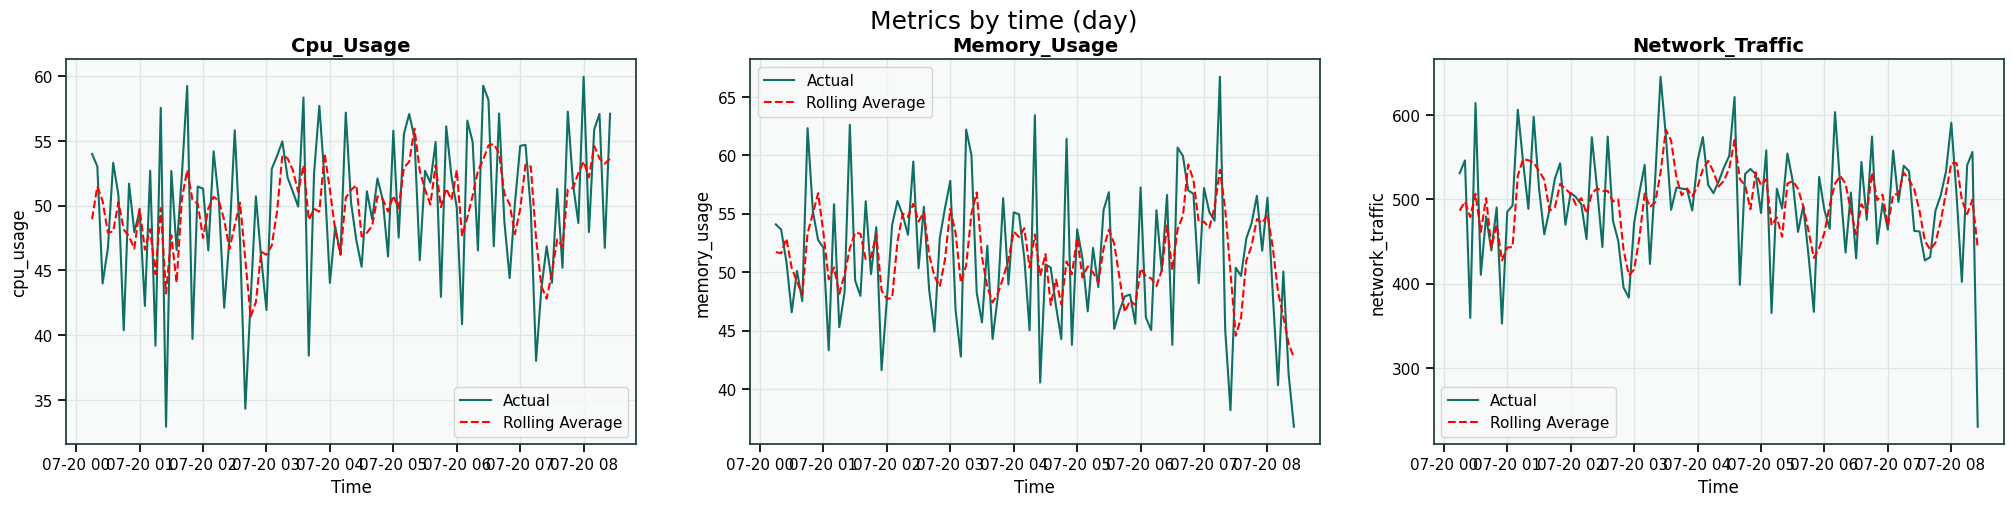

In [209]:
fig, axs = plt.subplots(ncols = 3, figsize=(25, 5))
axs = axs.flatten()
for i, col in enumerate(["cpu_usage","memory_usage","network_traffic"]):
    sns.lineplot(data = df_sampled_train, y = col, x = "timestamp", ax=axs[i], label = "Actual")
    sns.lineplot(data = df_sampled_train, y = f"{col}_rolling_average", x = "timestamp", ax=axs[i], color = "red", label = "Rolling Average", linestyle = "--")

    axs[i].set_title(col.title(), fontsize=14, fontweight="bold")
    axs[i].set_xlabel("Time")


plt.suptitle("Metrics by time (day)", fontsize = 18)

### Test Data

In [29]:
df_sampled_test.describe()

,cpu_usage,memory_usage,network_traffic,cpu_usage_lag-1,cpu_usage_lag-2,cpu_usage_lag-3,memory_usage_lag-1,memory_usage_lag-2,memory_usage_lag-3,network_traffic_lag-1,network_traffic_lag-2,network_traffic_lag-3,cpu_usage_rolling_average,memory_usage_rolling_average,network_traffic_rolling_average,hour,day,day_of_week
count,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00
mean,51.35,49.70,485.96,51.69,51.64,51.91,49.71,49.83,49.91,488.88,490.78,491.73,51.56,49.75,488.54,9.90,20.00,3.00
std,6.24,5.90,59.34,6.22,6.20,5.92,5.92,5.95,6.03,58.06,58.13,59.46,2.87,3.30,34.06,1.01,0.00,0.00
min,36.75,34.88,345.35,36.75,36.75,36.75,34.88,34.88,34.88,345.35,345.35,345.35,45.36,43.65,412.72,8.00,20.00,3.00
25%,48.00,46.41,441.34,48.68,48.68,49.62,46.41,46.41,46.41,450.69,453.17,453.17,49.01,47.49,466.76,9.00,20.00,3.00
50%,52.20,50.57,487.06,52.90,52.49,52.49,50.57,50.88,50.88,488.72,494.28,494.28,51.45,49.81,494.45,10.00,20.00,3.00
75%,55.54,54.64,528.36,55.59,55.59,55.59,54.64,54.64,54.73,528.36,532.96,532.96,53.76,52.69,512.42,11.00,20.00,3.00
max,63.05,61.78,588.84,63.05,63.05,63.05,61.78,61.78,61.78,588.84,588.84,591.23,57.42,56.69,552.93,12.00,20.00,3.00


Text(0.5, 0.98, 'Metrics by time (day)')

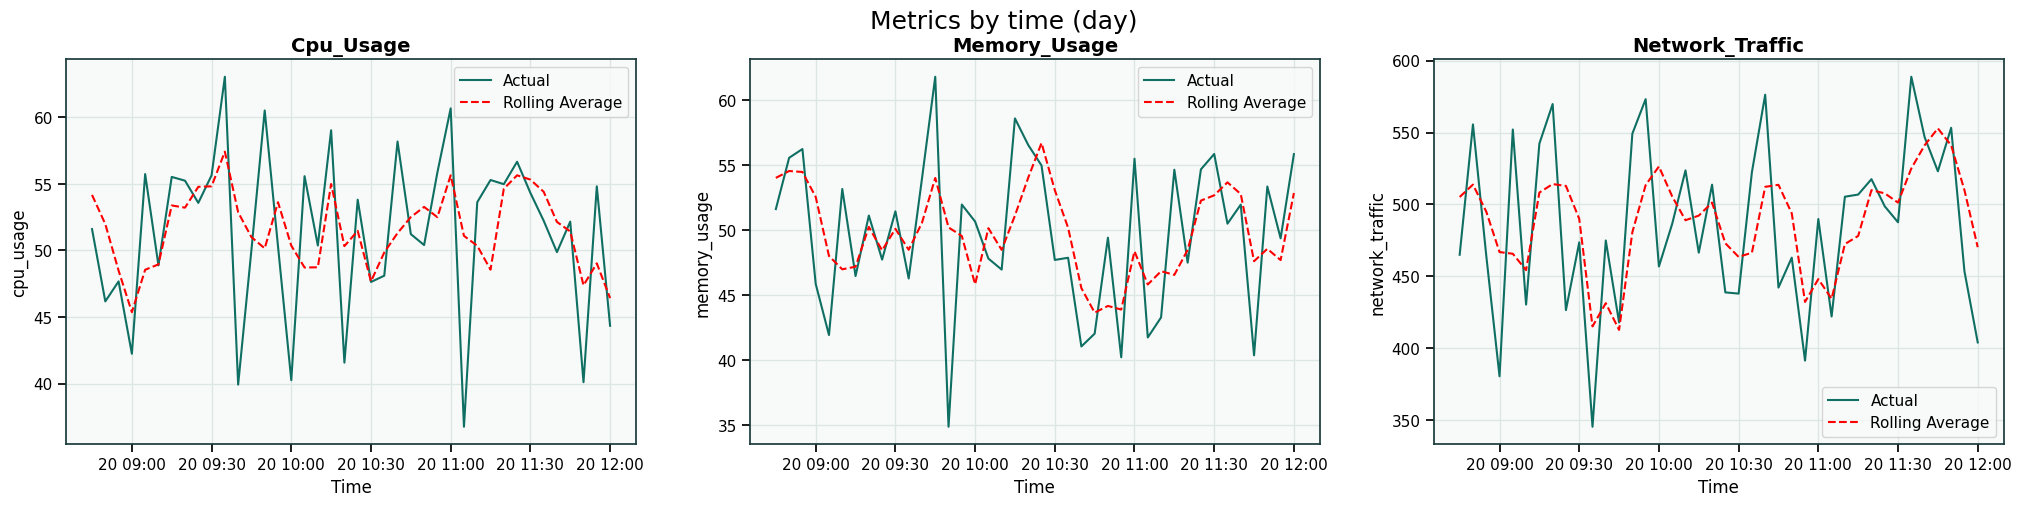

In [210]:
fig, axs = plt.subplots(ncols = 3, figsize=(25, 5))
axs = axs.flatten()
for i, col in enumerate(["cpu_usage","memory_usage","network_traffic"]):
    sns.lineplot(data = df_sampled_test, y = col, x = "timestamp", ax=axs[i], label = "Actual")
    sns.lineplot(data = df_sampled_test, y = f"{col}_rolling_average", x = "timestamp", ax=axs[i], color = "red", label = "Rolling Average", linestyle = "--")

    axs[i].set_title(col.title(), fontsize=14, fontweight="bold")
    axs[i].set_xlabel("Time")


plt.suptitle("Metrics by time (day)", fontsize = 18)

#### Normalization

In [211]:
exclude_scaling = ["hour", "day", "day_of_week","is_weekend"]
scaler = MinMaxScaler()

# train data is fitted on normalization scaler
scaled_data = pd.DataFrame(scaler.fit_transform(df_sampled_train.drop(columns=exclude_scaling, axis=1)), 
                columns = scaler.get_feature_names_out(), index=df_sampled_train.index) 

df_sampled_train = pd.concat([scaled_data,df_sampled_train[["hour", "day", "day_of_week","is_weekend"]]], axis=1)

In [212]:
# test data using same scaler
scaled_data = pd.DataFrame(scaler.transform(df_sampled_test.drop(columns=exclude_scaling, axis=1)), 
                columns = scaler.get_feature_names_out(), index=df_sampled_test.index) 

df_sampled_test = pd.concat([scaled_data,df_sampled_test[["hour", "day", "day_of_week","is_weekend"]]], axis=1)

In [219]:
df_sampled_train.head()

,cpu_usage,memory_usage,network_traffic,cpu_usage_lag-1,cpu_usage_lag-2,cpu_usage_lag-3,memory_usage_lag-1,memory_usage_lag-2,memory_usage_lag-3,network_traffic_lag-1,network_traffic_lag-2,network_traffic_lag-3,cpu_usage_rolling_average,memory_usage_rolling_average,network_traffic_rolling_average,hour,day,day_of_week,is_weekend
timestamp,,,,,,,,,,,,,,,,,,,
2023-07-20 00:15:00,0.78,0.58,0.72,0.54,0.46,0.60,0.31,0.55,0.36,0.21,0.55,0.62,0.52,0.55,0.44,0,20,3,False
2023-07-20 00:20:00,0.74,0.56,0.76,0.78,0.54,0.46,0.56,0.31,0.55,0.61,0.21,0.55,0.69,0.54,0.51,0,20,3,False
2023-07-20 00:25:00,0.41,0.47,0.31,0.74,0.78,0.54,0.54,0.56,0.31,0.66,0.61,0.21,0.61,0.62,0.40,0,20,3,False
2023-07-20 00:30:00,0.51,0.33,0.92,0.41,0.74,0.78,0.45,0.54,0.56,0.02,0.66,0.61,0.45,0.46,0.56,0,20,3,False
2023-07-20 00:35:00,0.75,0.45,0.43,0.51,0.41,0.74,0.29,0.45,0.54,0.89,0.02,0.66,0.45,0.39,0.30,0,20,3,False


In [220]:
df_sampled_test.head()

,cpu_usage,memory_usage,network_traffic,cpu_usage_lag-1,cpu_usage_lag-2,cpu_usage_lag-3,memory_usage_lag-1,memory_usage_lag-2,memory_usage_lag-3,network_traffic_lag-1,network_traffic_lag-2,network_traffic_lag-3,cpu_usage_rolling_average,memory_usage_rolling_average,network_traffic_rolling_average,hour,day,day_of_week,is_weekend
timestamp,,,,,,,,,,,,,,,,,,,
2023-07-20 08:45:00,0.69,0.50,0.57,0.93,0.73,0.66,0.64,0.55,0.65,0.57,0.61,0.82,0.88,0.68,0.55,8,20,3,False
2023-07-20 08:50:00,0.49,0.63,0.78,0.69,0.93,0.73,0.47,0.64,0.55,0.38,0.57,0.61,0.73,0.72,0.60,8,20,3,False
2023-07-20 08:55:00,0.55,0.65,0.56,0.49,0.69,0.93,0.61,0.47,0.64,0.69,0.38,0.57,0.49,0.71,0.49,8,20,3,False
2023-07-20 09:00:00,0.34,0.30,0.36,0.55,0.49,0.69,0.63,0.61,0.47,0.38,0.69,0.38,0.27,0.60,0.33,9,20,3,False
2023-07-20 09:05:00,0.84,0.17,0.78,0.34,0.55,0.49,0.27,0.63,0.61,0.10,0.38,0.69,0.49,0.32,0.32,9,20,3,False
